# 4. Visualización de Resultados

Comparación de experimentos de entrenamiento para detección de exoplanetas.

**Experimentos**: Combinaciones de Loss Type (BCE, WBCE, Focal) × Stratified Sampling (True, False)

**Arquitecturas**: LSTM, BiLSTM, CNN (Scannell), CNN-BiLSTM-Attention (Thomas)

## Estructura
- **4.1** Cargar y filtrar resultados
- **4.2** Comparación entre arquitecturas
- **4.3** Métricas por combinación (por arquitectura)
- **4.4** Heatmaps: F1-Score y AUC-PR
- **4.5** Tiempo de entrenamiento
- **4.6** Ranking y mejor configuración
- **4.7** Resumen final

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['figure.facecolor'] = '#ffffff'

# Paleta personalizada (tonos profesionales)
COLORS = {
    'primary': ['#2563eb', '#7c3aed', '#059669', '#d97706', '#dc2626'],
    'metrics': ['#3b82f6', '#8b5cf6', '#10b981', '#14b8a6', '#f59e0b', '#ef4444'],
    'loss': {'BCE': '#3b82f6', 'WBCE': '#10b981', 'Focal': '#f59e0b'},
    'stratified': {True: '#8b5cf6', False: '#f59e0b'},
    'combo': {
        'BCE + Stratified': '#3b82f6',
        'BCE + No Stratified': '#60a5fa',
        'WBCE + Stratified': '#10b981',
        'WBCE + No Stratified': '#34d399',
        'Focal + Stratified': '#f59e0b',
        'Focal + No Stratified': '#fbbf24',
    },
    'arch': {
        'LSTM': '#3b82f6',
        'BiLSTM': '#8b5cf6', 
        'CNN': '#10b981',
        'CNN-BiLSTM-Att': '#f59e0b',
    }
}
sns.set_palette(COLORS['metrics'])

# Cargar resultados
RESULTS_FILE = Path("data/results.csv")
df_all = pd.read_csv(RESULTS_FILE)

print(f"Total experimentos en archivo: {len(df_all)}")

# Filtrar solo experimentos "dual" (ignorar resultados anteriores)
df = df_all[df_all['experiment_name'].str.contains('dual', case=False, na=False)].copy()

print(f"Experimentos 'dual' (filtrados): {len(df)}")

# Separar LSTM, BiLSTM, CNN y CNN-BiLSTM-Attention experiments
df_lstm = df[df['experiment_name'].str.startswith('lstm_dual', na=False)].copy()
df_bilstm = df[df['experiment_name'].str.startswith('bilstm_dual', na=False)].copy()
df_cnn = df[df['experiment_name'].str.startswith('cnn_dual', na=False)].copy()
df_thomas = df[df['experiment_name'].str.startswith('cnn-bilstm-attention_dual', na=False)].copy()

# Fix: Corregir use_stratified_sampling basándose en el nombre del experimento
# (algunos experimentos tienen el valor incorrecto en el CSV)
def fix_stratified_from_name(row):
    name = row['experiment_name']
    if '_no_strat' in name:
        return False
    elif '_strat' in name:
        return True
    return row['use_stratified_sampling']

df['use_stratified_sampling'] = df.apply(fix_stratified_from_name, axis=1)
df_thomas['use_stratified_sampling'] = df_thomas.apply(fix_stratified_from_name, axis=1)

print(f"  - LSTM dual: {len(df_lstm)}")
print(f"  - BiLSTM dual: {len(df_bilstm)}")
print(f"  - CNN dual: {len(df_cnn)}")
print(f"  - CNN-BiLSTM-Attention: {len(df_thomas)}")

df

Total experimentos en archivo: 156
Experimentos 'dual' (filtrados): 120
  - LSTM dual: 30
  - BiLSTM dual: 30
  - CNN dual: 30
  - CNN-BiLSTM-Attention: 30


,experiment_name,timestamp,model_type,loss_type,use_global,use_local,hidden_size,num_layers,dropout,bidirectional,...,bilstm_dropout,fc_dropout,weight_decay,max_grad_norm,use_stratified_sampling,use_scheduler,final_lr,experiment_base,iteration,seed
36,lstm_dual_bce_strat_0,2026-01-10 23:16:29,LSTM,BCE,True,True,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0002,1.0,True,True,0.000050,lstm_dual_bce_strat,0.0,42.0
37,lstm_dual_bce_strat_1,2026-01-10 23:21:51,LSTM,BCE,True,True,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0002,1.0,True,True,0.000050,lstm_dual_bce_strat,1.0,43.0
38,lstm_dual_bce_strat_2,2026-01-10 23:27:19,LSTM,BCE,True,True,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0002,1.0,True,True,0.000050,lstm_dual_bce_strat,2.0,44.0
39,lstm_dual_bce_strat_3,2026-01-10 23:33:25,LSTM,BCE,True,True,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0002,1.0,True,True,0.000025,lstm_dual_bce_strat,3.0,45.0
40,lstm_dual_bce_strat_4,2026-01-10 23:42:30,LSTM,BCE,True,True,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0002,1.0,True,True,0.000013,lstm_dual_bce_strat,4.0,46.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,cnn-bilstm-attention_dual_focal_no_strat_0,2026-01-11 18:40:24,CNN-BiLSTM-Attention,Focal,True,True,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0002,1.0,False,True,0.000050,cnn-bilstm-attention_dual_focal_no_strat,0.0,42.0
152,cnn-bilstm-attention_dual_focal_no_strat_1,2026-01-11 18:45:23,CNN-BiLSTM-Attention,Focal,True,True,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0002,1.0,False,True,0.000050,cnn-bilstm-attention_dual_focal_no_strat,1.0,43.0
153,cnn-bilstm-attention_dual_focal_no_strat_2,2026-01-11 18:48:48,CNN-BiLSTM-Attention,Focal,True,True,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0002,1.0,False,True,0.000025,cnn-bilstm-attention_dual_focal_no_strat,2.0,44.0
154,cnn-bilstm-attention_dual_focal_no_strat_3,2026-01-11 18:51:09,CNN-BiLSTM-Attention,Focal,True,True,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0002,1.0,False,True,0.000050,cnn-bilstm-attention_dual_focal_no_strat,3.0,45.0


In [2]:
# ============================================================
# CALCULAR MEDIA Y DESVIACIÓN ESTÁNDAR POR COMBINACIÓN
# ============================================================
# Agrupa por: loss_type + use_stratified_sampling

import re

# Añadir columna de combinación para visualización
for df_temp in [df, df_lstm, df_bilstm, df_cnn, df_thomas]:
    if len(df_temp) > 0:
        df_temp['stratified_label'] = df_temp['use_stratified_sampling'].apply(lambda x: 'Stratified' if x else 'No Stratified')
        df_temp['combo'] = df_temp['loss_type'] + ' + ' + df_temp['stratified_label']

# Si no existe experiment_base, crearlo
if 'experiment_base' not in df.columns:
    def get_base_experiment_name(name: str) -> str:
        match = re.match(r'^(.+)_(\d+)$', name)
        if match:
            return match.group(1)
        return name
    for df_temp in [df, df_lstm, df_bilstm, df_cnn, df_thomas]:
        if len(df_temp) > 0:
            df_temp['experiment_base'] = df_temp['experiment_name'].apply(get_base_experiment_name)

# Agrupar por combinación (loss_type + stratified)
combos_global = df.groupby(['loss_type', 'use_stratified_sampling']).size().reset_index(name='n_iterations')
combos = df_lstm.groupby(['loss_type', 'use_stratified_sampling']).size().reset_index(name='n_iterations') if len(df_lstm) > 0 else pd.DataFrame()
combos_bilstm = df_bilstm.groupby(['loss_type', 'use_stratified_sampling']).size().reset_index(name='n_iterations') if len(df_bilstm) > 0 else pd.DataFrame()
combos_cnn = df_cnn.groupby(['loss_type', 'use_stratified_sampling']).size().reset_index(name='n_iterations') if len(df_cnn) > 0 else pd.DataFrame()
combos_thomas = df_thomas.groupby(['loss_type', 'use_stratified_sampling']).size().reset_index(name='n_iterations') if len(df_thomas) > 0 else pd.DataFrame()

if len(combos) > 0:
    print(f"Combinaciones LSTM encontradas:")
    for _, row in combos.iterrows():
        strat = 'Stratified' if row['use_stratified_sampling'] else 'No Stratified'
        print(f"  - {row['loss_type']} + {strat}: {row['n_iterations']} iteraciones")
else:
    print(f"⚠️ No hay experimentos LSTM dual aún")

if len(combos_bilstm) > 0:
    print(f"\nCombinaciones BiLSTM encontradas:")
    for _, row in combos_bilstm.iterrows():
        strat = 'Stratified' if row['use_stratified_sampling'] else 'No Stratified'
        print(f"  - {row['loss_type']} + {strat}: {row['n_iterations']} iteraciones")
else:
    print(f"\n⚠️ No hay experimentos BiLSTM dual aún")

if len(combos_cnn) > 0:
    print(f"\nCombinaciones CNN encontradas:")
    for _, row in combos_cnn.iterrows():
        strat = 'Stratified' if row['use_stratified_sampling'] else 'No Stratified'
        print(f"  - {row['loss_type']} + {strat}: {row['n_iterations']} iteraciones")
else:
    print(f"\n⚠️ No hay experimentos CNN dual aún")

if len(combos_thomas) > 0:
    print(f"\nCombinaciones CNN-BiLSTM-Attention (Thomas) encontradas:")
    for _, row in combos_thomas.iterrows():
        strat = 'Stratified' if row['use_stratified_sampling'] else 'No Stratified'
        print(f"  - {row['loss_type']} + {strat}: {row['n_iterations']} iteraciones")
else:
    print(f"\n⚠️ No hay experimentos CNN-BiLSTM-Attention (Thomas) aún")

# ============================================================
# TABLA DE RESULTADOS AGREGADOS (media ± std)
# ============================================================
metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_auc_roc', 'test_auc_pr']

def aggregate_by_combos(data_df, combos_df, model_name='LSTM'):
    """Agrega resultados por combinación de loss_type y stratified_sampling."""
    results = []
    for _, combo_row in combos_df.iterrows():
        loss_type = combo_row['loss_type']
        use_strat = combo_row['use_stratified_sampling']
        strat_label = 'Stratified' if use_strat else 'No Stratified'
        
        exp_df = data_df[(data_df['loss_type'] == loss_type) & (data_df['use_stratified_sampling'] == use_strat)]
        n_iters = len(exp_df)
        
        result = {
            'loss_type': loss_type,
            'use_stratified_sampling': use_strat,
            'stratified_label': strat_label,
            'combo': f"{loss_type} + {strat_label}",
            'n_iterations': n_iters,
            'model_type': model_name,
        }
        
        for metric in metrics:
            values = exp_df[metric].values
            result[f'{metric}_mean'] = np.mean(values)
            result[f'{metric}_std'] = np.std(values)
            result[f'{metric}_str'] = f"{np.mean(values)*100:.2f} ± {np.std(values)*100:.2f}"
        
        results.append(result)
    return pd.DataFrame(results)

print(f"\n{'='*100}")
print("RESULTADOS AGREGADOS (media ± std)")
print(f"{'='*100}")

# Agregar Global (todos los experimentos dual)
agg_df_global = aggregate_by_combos(df, combos_global, 'Global')

# Agregar LSTM
agg_df = aggregate_by_combos(df_lstm, combos, 'LSTM') if len(combos) > 0 else pd.DataFrame()

# Agregar BiLSTM (si hay datos)
agg_df_bilstm = aggregate_by_combos(df_bilstm, combos_bilstm, 'BiLSTM') if len(combos_bilstm) > 0 else pd.DataFrame()

# Agregar CNN (si hay datos)
agg_df_cnn = aggregate_by_combos(df_cnn, combos_cnn, 'CNN') if len(combos_cnn) > 0 else pd.DataFrame()

# Agregar CNN-BiLSTM-Attention / Thomas (si hay datos)
agg_df_thomas = aggregate_by_combos(df_thomas, combos_thomas, 'CNN-BiLSTM-Att') if len(combos_thomas) > 0 else pd.DataFrame()

# Mostrar tabla formateada
print(f"\n{'Combinación':<25} {'N':>3} {'Accuracy':>15} {'F1':>15} {'AUC-ROC':>15} {'AUC-PR':>15}")
print("-" * 100)
for _, row in agg_df.iterrows():
    print(f"{row['combo']:<25} {row['n_iterations']:>3} "
          f"{row['test_accuracy_str']:>15} "
          f"{row['test_f1_str']:>15} "
          f"{row['test_auc_roc_str']:>15} "
          f"{row['test_auc_pr_str']:>15}")

# Guardar tabla agregada
agg_df.to_csv("data/results_aggregated.csv", index=False)
print(f"\n✓ Resultados agregados guardados en: data/results_aggregated.csv")

Combinaciones LSTM encontradas:
  - BCE + No Stratified: 5 iteraciones
  - BCE + Stratified: 5 iteraciones
  - Focal + No Stratified: 5 iteraciones
  - Focal + Stratified: 5 iteraciones
  - WBCE + No Stratified: 5 iteraciones
  - WBCE + Stratified: 5 iteraciones

Combinaciones BiLSTM encontradas:
  - BCE + No Stratified: 5 iteraciones
  - BCE + Stratified: 5 iteraciones
  - Focal + No Stratified: 5 iteraciones
  - Focal + Stratified: 5 iteraciones
  - WBCE + No Stratified: 5 iteraciones
  - WBCE + Stratified: 5 iteraciones

Combinaciones CNN encontradas:
  - BCE + No Stratified: 5 iteraciones
  - BCE + Stratified: 5 iteraciones
  - Focal + No Stratified: 5 iteraciones
  - Focal + Stratified: 5 iteraciones
  - WBCE + No Stratified: 5 iteraciones
  - WBCE + Stratified: 5 iteraciones

Combinaciones CNN-BiLSTM-Attention (Thomas) encontradas:
  - BCE + No Stratified: 5 iteraciones
  - BCE + Stratified: 5 iteraciones
  - Focal + No Stratified: 5 iteraciones
  - Focal + Stratified: 5 iteracio

In [3]:
# ============================================================
# COMPARACIÓN ENTRE ARQUITECTURAS: LSTM vs BiLSTM vs CNN
# ============================================================

# Agregar resultados por arquitectura
metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_auc_roc', 'test_auc_pr']
arch_results = []

for arch_name, arch_df in [('LSTM', df_lstm), ('BiLSTM', df_bilstm), ('CNN', df_cnn), ('CNN-BiLSTM-Att', df_thomas)]:
    if len(arch_df) > 0:
        result = {'architecture': arch_name, 'n_experiments': len(arch_df)}
        for metric in metrics:
            result[f'{metric}_mean'] = arch_df[metric].mean()
            result[f'{metric}_std'] = arch_df[metric].std()
        # Tiempo de entrenamiento
        result['time_mean'] = arch_df['total_time_sec'].mean() / 60  # en minutos
        result['time_std'] = arch_df['total_time_sec'].std() / 60
        result['epochs_mean'] = arch_df['actual_epochs'].mean()
        result['epochs_std'] = arch_df['actual_epochs'].std()
        arch_results.append(result)

arch_df_agg = pd.DataFrame(arch_results)

if len(arch_df_agg) > 0:
    print("📊 COMPARACIÓN ENTRE ARQUITECTURAS")
    print("=" * 80)
    for _, row in arch_df_agg.iterrows():
        print(f"\n{row['architecture']} ({row['n_experiments']} experimentos):")
        print(f"  F1-Score:  {row['test_f1_mean']*100:.2f} ± {row['test_f1_std']*100:.2f}%")
        print(f"  AUC-ROC:   {row['test_auc_roc_mean']*100:.2f} ± {row['test_auc_roc_std']*100:.2f}%")
        print(f"  Tiempo:    {row['time_mean']:.1f} ± {row['time_std']:.1f} min")
        print(f"  Épocas:    {row['epochs_mean']:.0f} ± {row['epochs_std']:.0f}")
else:
    print("⚠️ No hay suficientes datos para comparar arquitecturas")

📊 COMPARACIÓN ENTRE ARQUITECTURAS

LSTM (30 experimentos):
  F1-Score:  81.36 ± 2.50%
  AUC-ROC:   96.84 ± 0.51%
  Tiempo:    8.8 ± 3.6 min
  Épocas:    44 ± 18

BiLSTM (30 experimentos):
  F1-Score:  82.32 ± 3.42%
  AUC-ROC:   97.35 ± 0.38%
  Tiempo:    19.5 ± 6.4 min
  Épocas:    44 ± 14

CNN (30 experimentos):
  F1-Score:  89.80 ± 1.62%
  AUC-ROC:   98.54 ± 0.14%
  Tiempo:    0.5 ± 0.1 min
  Épocas:    19 ± 4

CNN-BiLSTM-Att (30 experimentos):
  F1-Score:  77.97 ± 12.79%
  AUC-ROC:   97.89 ± 0.54%
  Tiempo:    3.7 ± 0.8 min
  Épocas:    24 ± 5


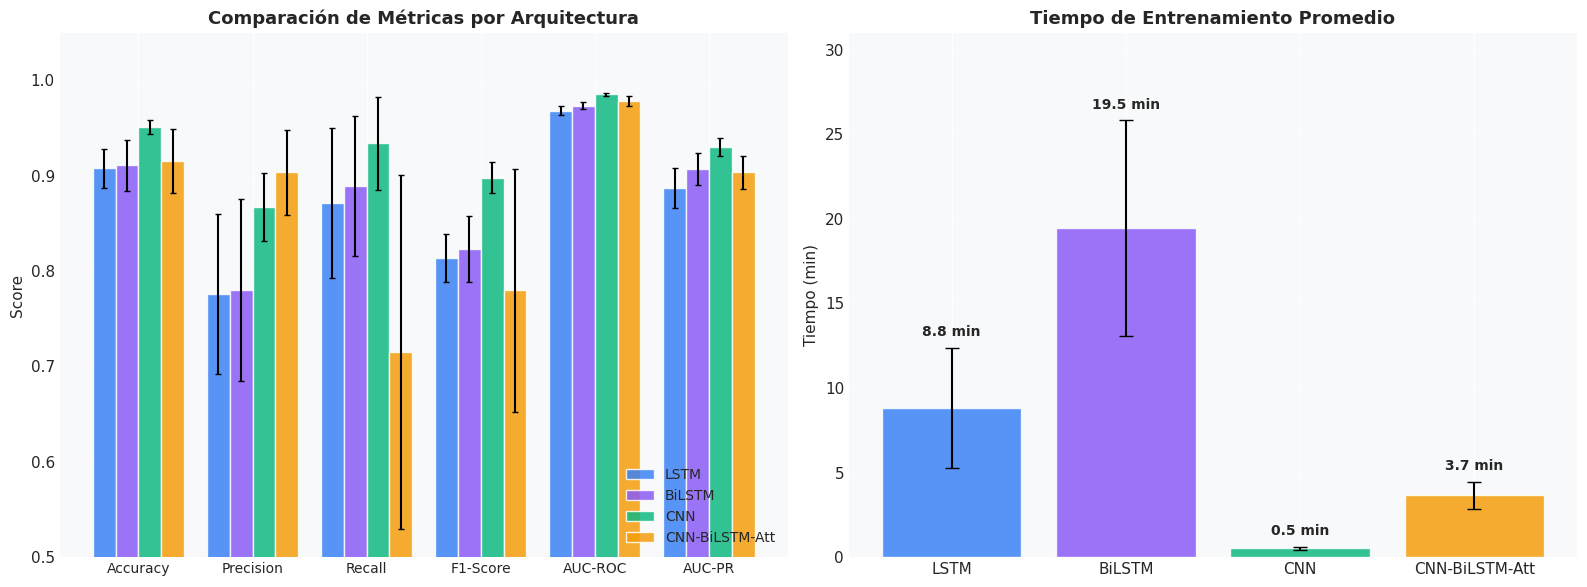


✓ Gráfico guardado en: data/comparison_architectures.png


In [16]:
# ============================================================
# GRÁFICO: Comparación de Arquitecturas (Métricas + Tiempo)
# ============================================================

if len(arch_df_agg) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- Subplot 1: Métricas de rendimiento ---
    ax1 = axes[0]
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']
    metric_cols = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_auc_roc', 'test_auc_pr']
    
    x = np.arange(len(metric_labels))
    n_arch = len(arch_df_agg)
    width = 0.8 / n_arch
    
    for i, (_, row) in enumerate(arch_df_agg.iterrows()):
        arch = row['architecture']
        means = [row[f'{m}_mean'] for m in metric_cols]
        stds = [row[f'{m}_std'] for m in metric_cols]
        offset = (i - n_arch/2 + 0.5) * width
        color = COLORS['arch'].get(arch, '#6b7280')
        ax1.bar(x + offset, means, width, label=f"{arch}", 
                yerr=stds, capsize=2, color=color, edgecolor='white', alpha=0.85)
    
    ax1.set_ylabel('Score', fontsize=11)
    ax1.set_title('Comparación de Métricas por Arquitectura', fontsize=13, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metric_labels, fontsize=10)
    ax1.legend(loc='lower right', fontsize=10)
    ax1.set_ylim(0.5, 1.05)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # --- Subplot 2: Tiempo de entrenamiento ---
    ax2 = axes[1]
    
    archs = arch_df_agg['architecture'].tolist()
    times = arch_df_agg['time_mean'].tolist()
    time_stds = arch_df_agg['time_std'].tolist()
    colors_arch = [COLORS['arch'].get(a, '#6b7280') for a in archs]
    
    bars = ax2.bar(archs, times, yerr=time_stds, capsize=5, color=colors_arch, edgecolor='white', alpha=0.85)
    
    # Texto encima de cada barra
    for bar, t, std in zip(bars, times, time_stds):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.5, 
                 f'{t:.1f} min', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_ylabel('Tiempo (min)', fontsize=11)
    ax2.set_title('Tiempo de Entrenamiento Promedio', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Ajustar límite Y
    max_time = max(times) + max(time_stds)
    ax2.set_ylim(0, max_time * 1.2)
    
    plt.tight_layout()
    plt.savefig('data/comparison_architectures.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Gráfico guardado en: data/comparison_architectures.png")
else:
    print("⚠️ No hay suficientes datos para generar el gráfico")

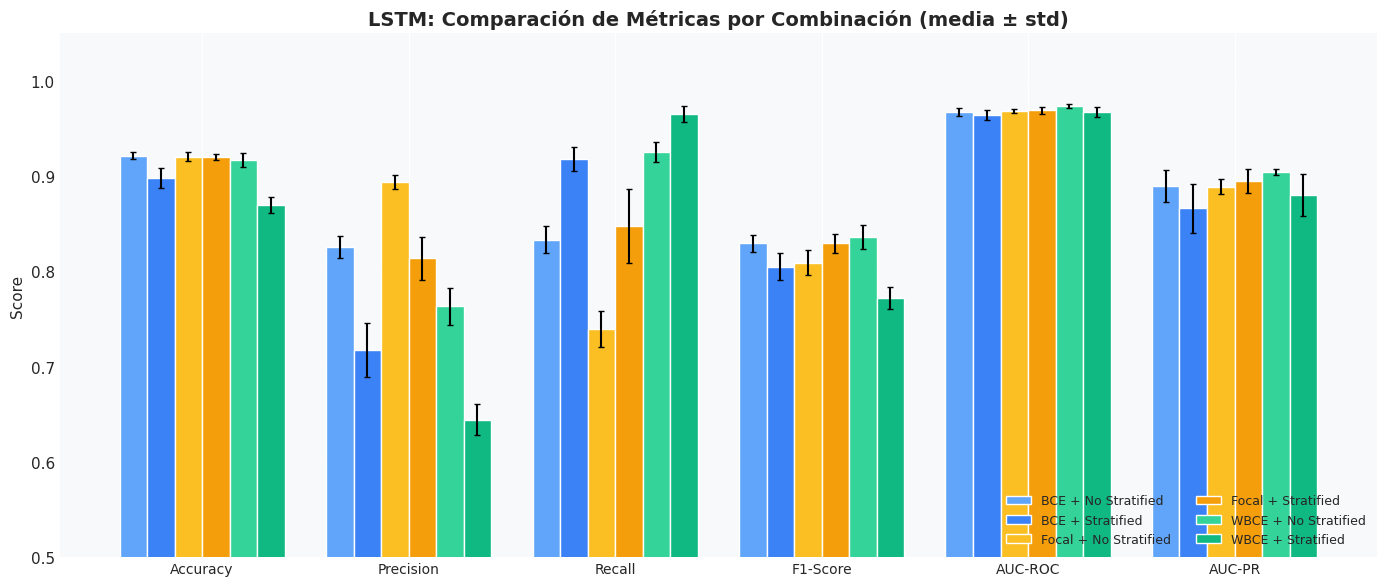

In [5]:
# ============================================================
# VISUALIZACIÓN 1a: Comparación de Métricas por Combinación (LSTM)
# ============================================================

if len(agg_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Métricas principales a visualizar (incluyendo Precision y Recall)
    main_metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_auc_roc', 'test_auc_pr']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']
    
    x = np.arange(len(main_metrics))
    n_combos = len(agg_df)
    width = 0.8 / n_combos
    
    for i, (_, row) in enumerate(agg_df.iterrows()):
        combo = row['combo']
        means = [row[f'{m}_mean'] for m in main_metrics]
        stds = [row[f'{m}_std'] for m in main_metrics]
        offset = (i - n_combos/2 + 0.5) * width
        color = COLORS['combo'].get(combo, '#6b7280')
        ax.bar(x + offset, means, width, label=combo, yerr=stds, capsize=2, color=color, edgecolor='white')
    
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('LSTM: Comparación de Métricas por Combinación (media ± std)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=10)
    ax.legend(loc='lower right', fontsize=9, ncol=2)
    ax.set_ylim(0.5, 1.05)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay experimentos para visualizar.")

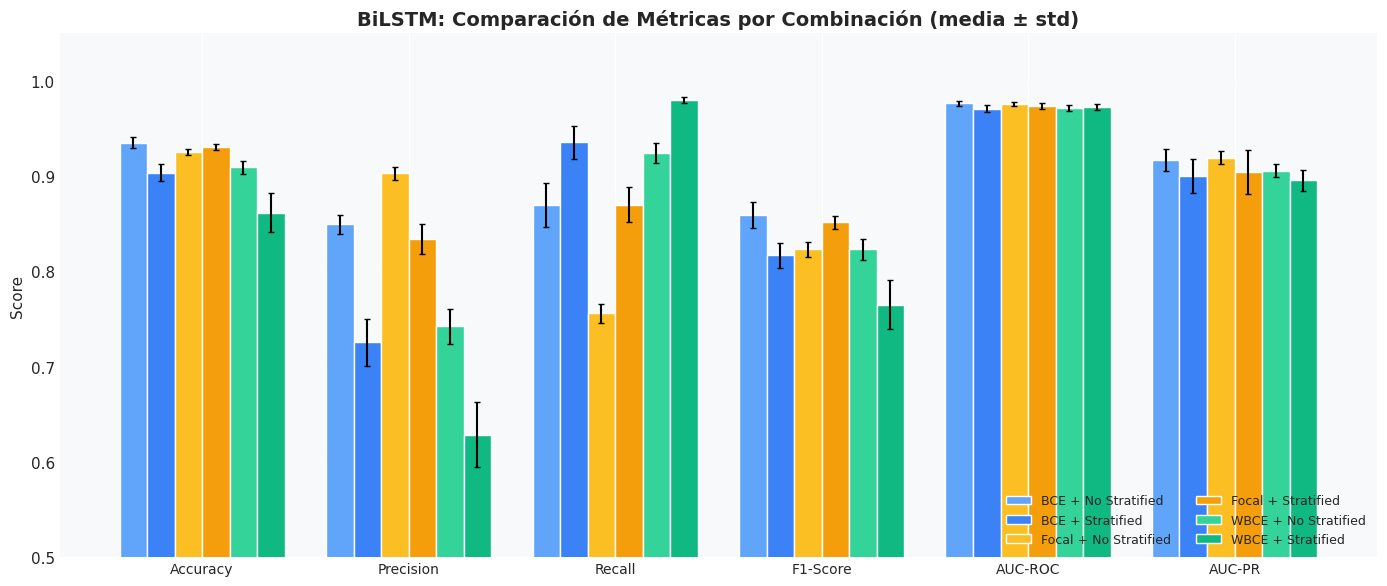

In [6]:
# ============================================================
# VISUALIZACIÓN 1b: Comparación de Métricas por Combinación (BiLSTM)
# ============================================================

if len(agg_df_bilstm) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Métricas principales a visualizar (incluyendo Precision y Recall)
    main_metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_auc_roc', 'test_auc_pr']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']
    
    x = np.arange(len(main_metrics))
    n_combos = len(agg_df_bilstm)
    width = 0.8 / n_combos
    
    for i, (_, row) in enumerate(agg_df_bilstm.iterrows()):
        combo = row['combo']
        means = [row[f'{m}_mean'] for m in main_metrics]
        stds = [row[f'{m}_std'] for m in main_metrics]
        offset = (i - n_combos/2 + 0.5) * width
        color = COLORS['combo'].get(combo, '#6b7280')
        ax.bar(x + offset, means, width, label=combo, yerr=stds, capsize=2, color=color, edgecolor='white')
    
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('BiLSTM: Comparación de Métricas por Combinación (media ± std)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=10)
    ax.legend(loc='lower right', fontsize=9, ncol=2)
    ax.set_ylim(0.5, 1.05)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No hay experimentos BiLSTM dual para visualizar.")

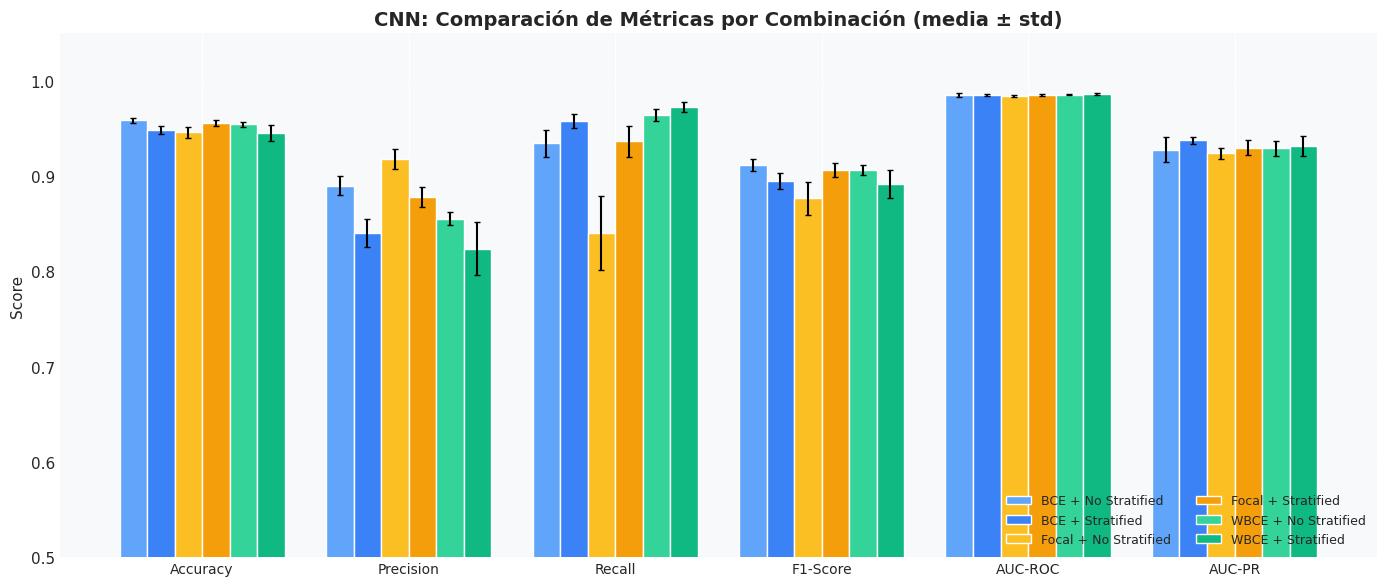

In [7]:
# ============================================================
# VISUALIZACIÓN 1c: Comparación de Métricas por Combinación (CNN)
# ============================================================

if len(agg_df_cnn) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Métricas principales a visualizar (incluyendo Precision y Recall)
    main_metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_auc_roc', 'test_auc_pr']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']
    
    x = np.arange(len(main_metrics))
    n_combos = len(agg_df_cnn)
    width = 0.8 / n_combos
    
    for i, (_, row) in enumerate(agg_df_cnn.iterrows()):
        combo = row['combo']
        means = [row[f'{m}_mean'] for m in main_metrics]
        stds = [row[f'{m}_std'] for m in main_metrics]
        offset = (i - n_combos/2 + 0.5) * width
        color = COLORS['combo'].get(combo, '#6b7280')
        ax.bar(x + offset, means, width, label=combo, yerr=stds, capsize=2, color=color, edgecolor='white')
    
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('CNN: Comparación de Métricas por Combinación (media ± std)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=10)
    ax.legend(loc='lower right', fontsize=9, ncol=2)
    ax.set_ylim(0.5, 1.05)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No hay experimentos CNN dual para visualizar.")

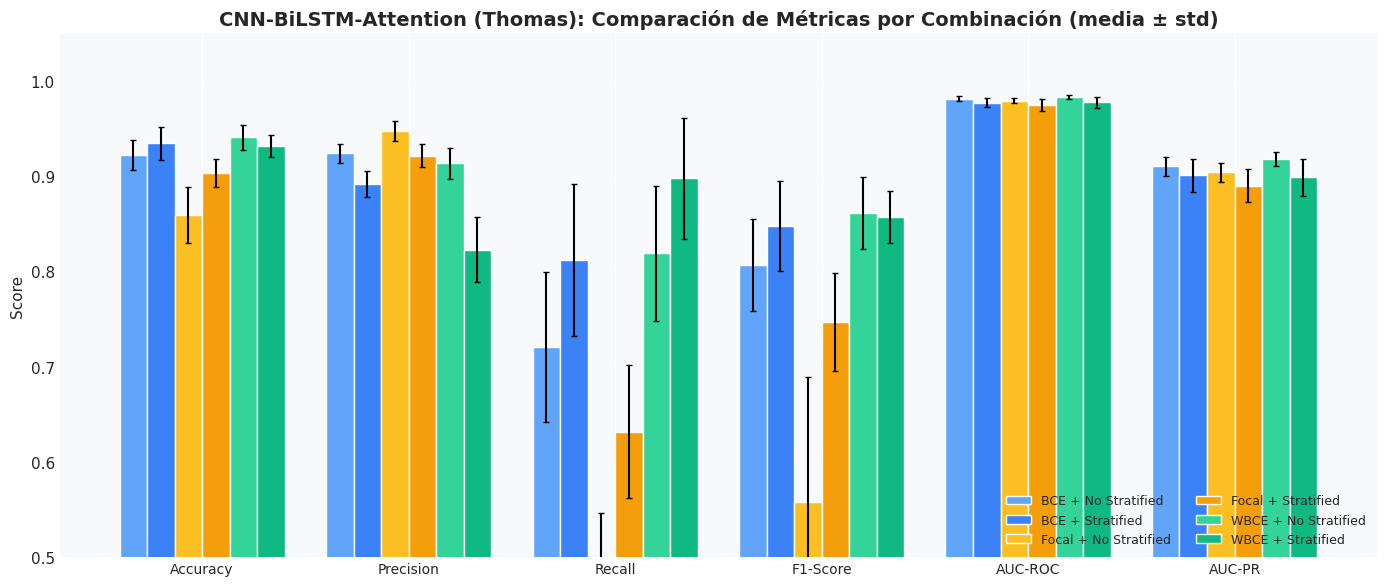

In [8]:
# ============================================================
# VISUALIZACIÓN 1d: Comparación de Métricas por Combinación (CNN-BiLSTM-Attention)
# ============================================================

if len(agg_df_thomas) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Métricas principales a visualizar (incluyendo Precision y Recall)
    main_metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_auc_roc', 'test_auc_pr']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']
    
    x = np.arange(len(main_metrics))
    n_combos = len(agg_df_thomas)
    width = 0.8 / n_combos
    
    for i, (_, row) in enumerate(agg_df_thomas.iterrows()):
        combo = row['combo']
        means = [row[f'{m}_mean'] for m in main_metrics]
        stds = [row[f'{m}_std'] for m in main_metrics]
        offset = (i - n_combos/2 + 0.5) * width
        color = COLORS['combo'].get(combo, '#6b7280')
        ax.bar(x + offset, means, width, label=combo, yerr=stds, capsize=2, color=color, edgecolor='white')
    
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('CNN-BiLSTM-Attention (Thomas): Comparación de Métricas por Combinación (media ± std)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=10)
    ax.legend(loc='lower right', fontsize=9, ncol=2)
    ax.set_ylim(0.5, 1.05)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No hay experimentos CNN-BiLSTM-Attention (Thomas) para visualizar.")

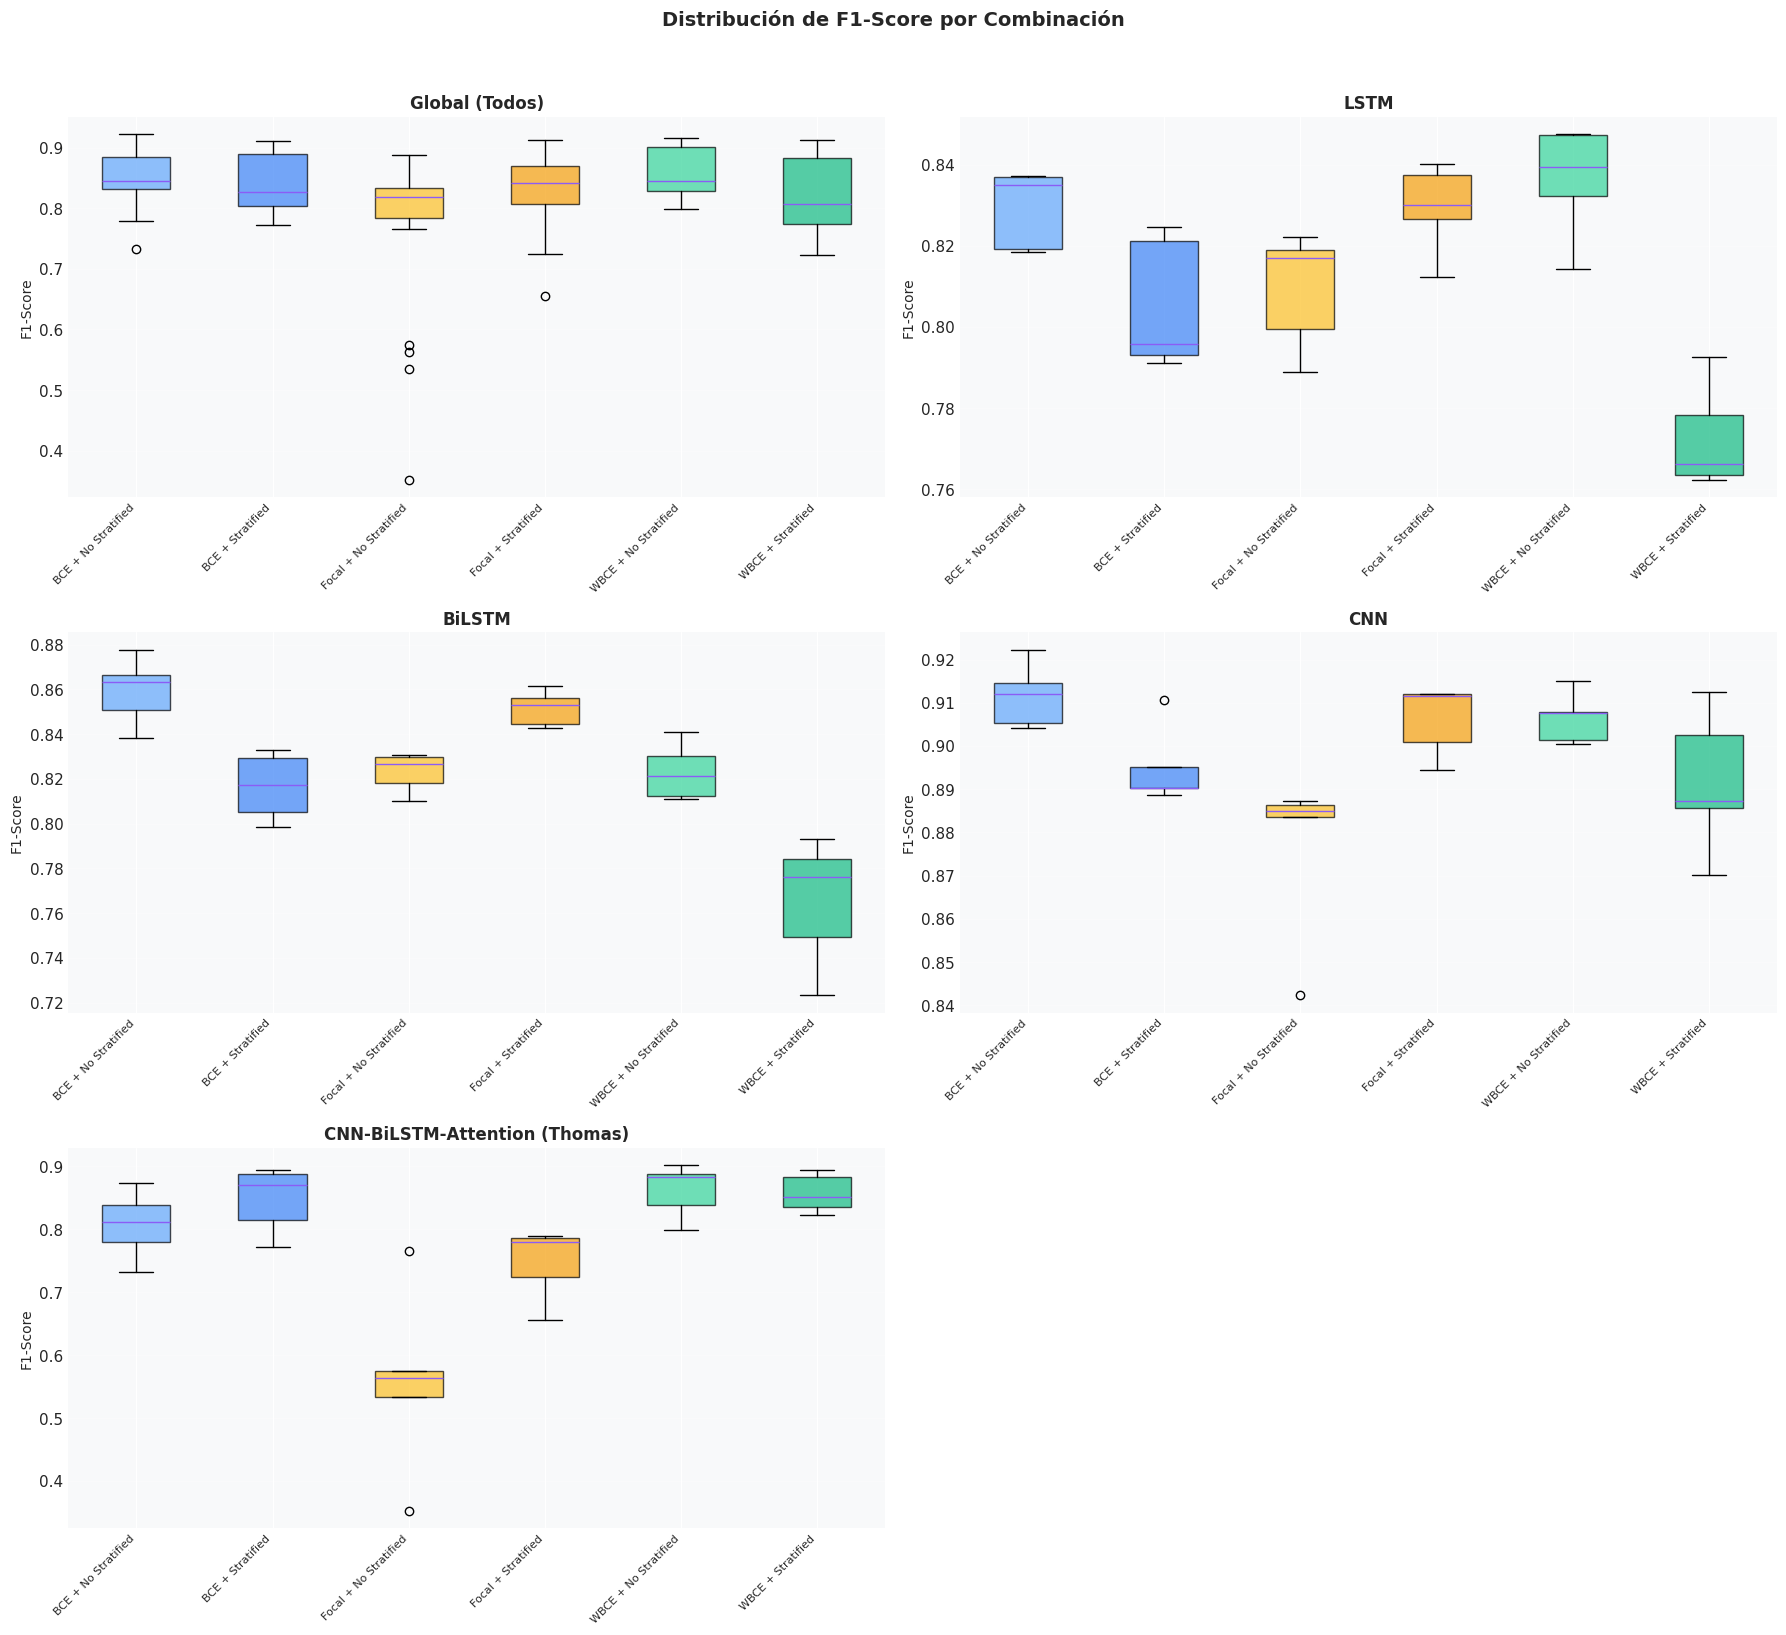

In [9]:
# ============================================================
# VISUALIZACIÓN 2: Distribución de F1-Score por Combinación (Boxplot)
# ============================================================
# 5 subplots: Global, LSTM, BiLSTM, CNN, CNN-BiLSTM-Att

def plot_f1_boxplot(ax, data_df, agg_data, title):
    """Genera boxplot de F1-Score para un conjunto de datos."""
    if len(agg_data) == 0:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(title, fontsize=12, fontweight='bold')
        return
    
    boxplot_data = []
    labels = []
    colors_box = []
    for _, row in agg_data.iterrows():
        combo = row['combo']
        combo_df = data_df[data_df['combo'] == combo]
        if len(combo_df) > 0:
            boxplot_data.append(combo_df['test_f1'].values)
            labels.append(combo)
            colors_box.append(COLORS['combo'].get(combo, '#6b7280'))
    
    if len(boxplot_data) > 0:
        bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True)
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
    
    ax.set_ylabel('F1-Score', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')
        label.set_fontsize(8)

fig, axes = plt.subplots(3, 2, figsize=(18, 16))

plot_f1_boxplot(axes[0, 0], df, agg_df_global, 'Global (Todos)')
plot_f1_boxplot(axes[0, 1], df_lstm, agg_df, 'LSTM')
plot_f1_boxplot(axes[1, 0], df_bilstm, agg_df_bilstm, 'BiLSTM')
plot_f1_boxplot(axes[1, 1], df_cnn, agg_df_cnn, 'CNN')
plot_f1_boxplot(axes[2, 0], df_thomas, agg_df_thomas, 'CNN-BiLSTM-Attention (Thomas)')
axes[2, 1].axis('off')  # Hide empty subplot

plt.suptitle('Distribución de F1-Score por Combinación', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

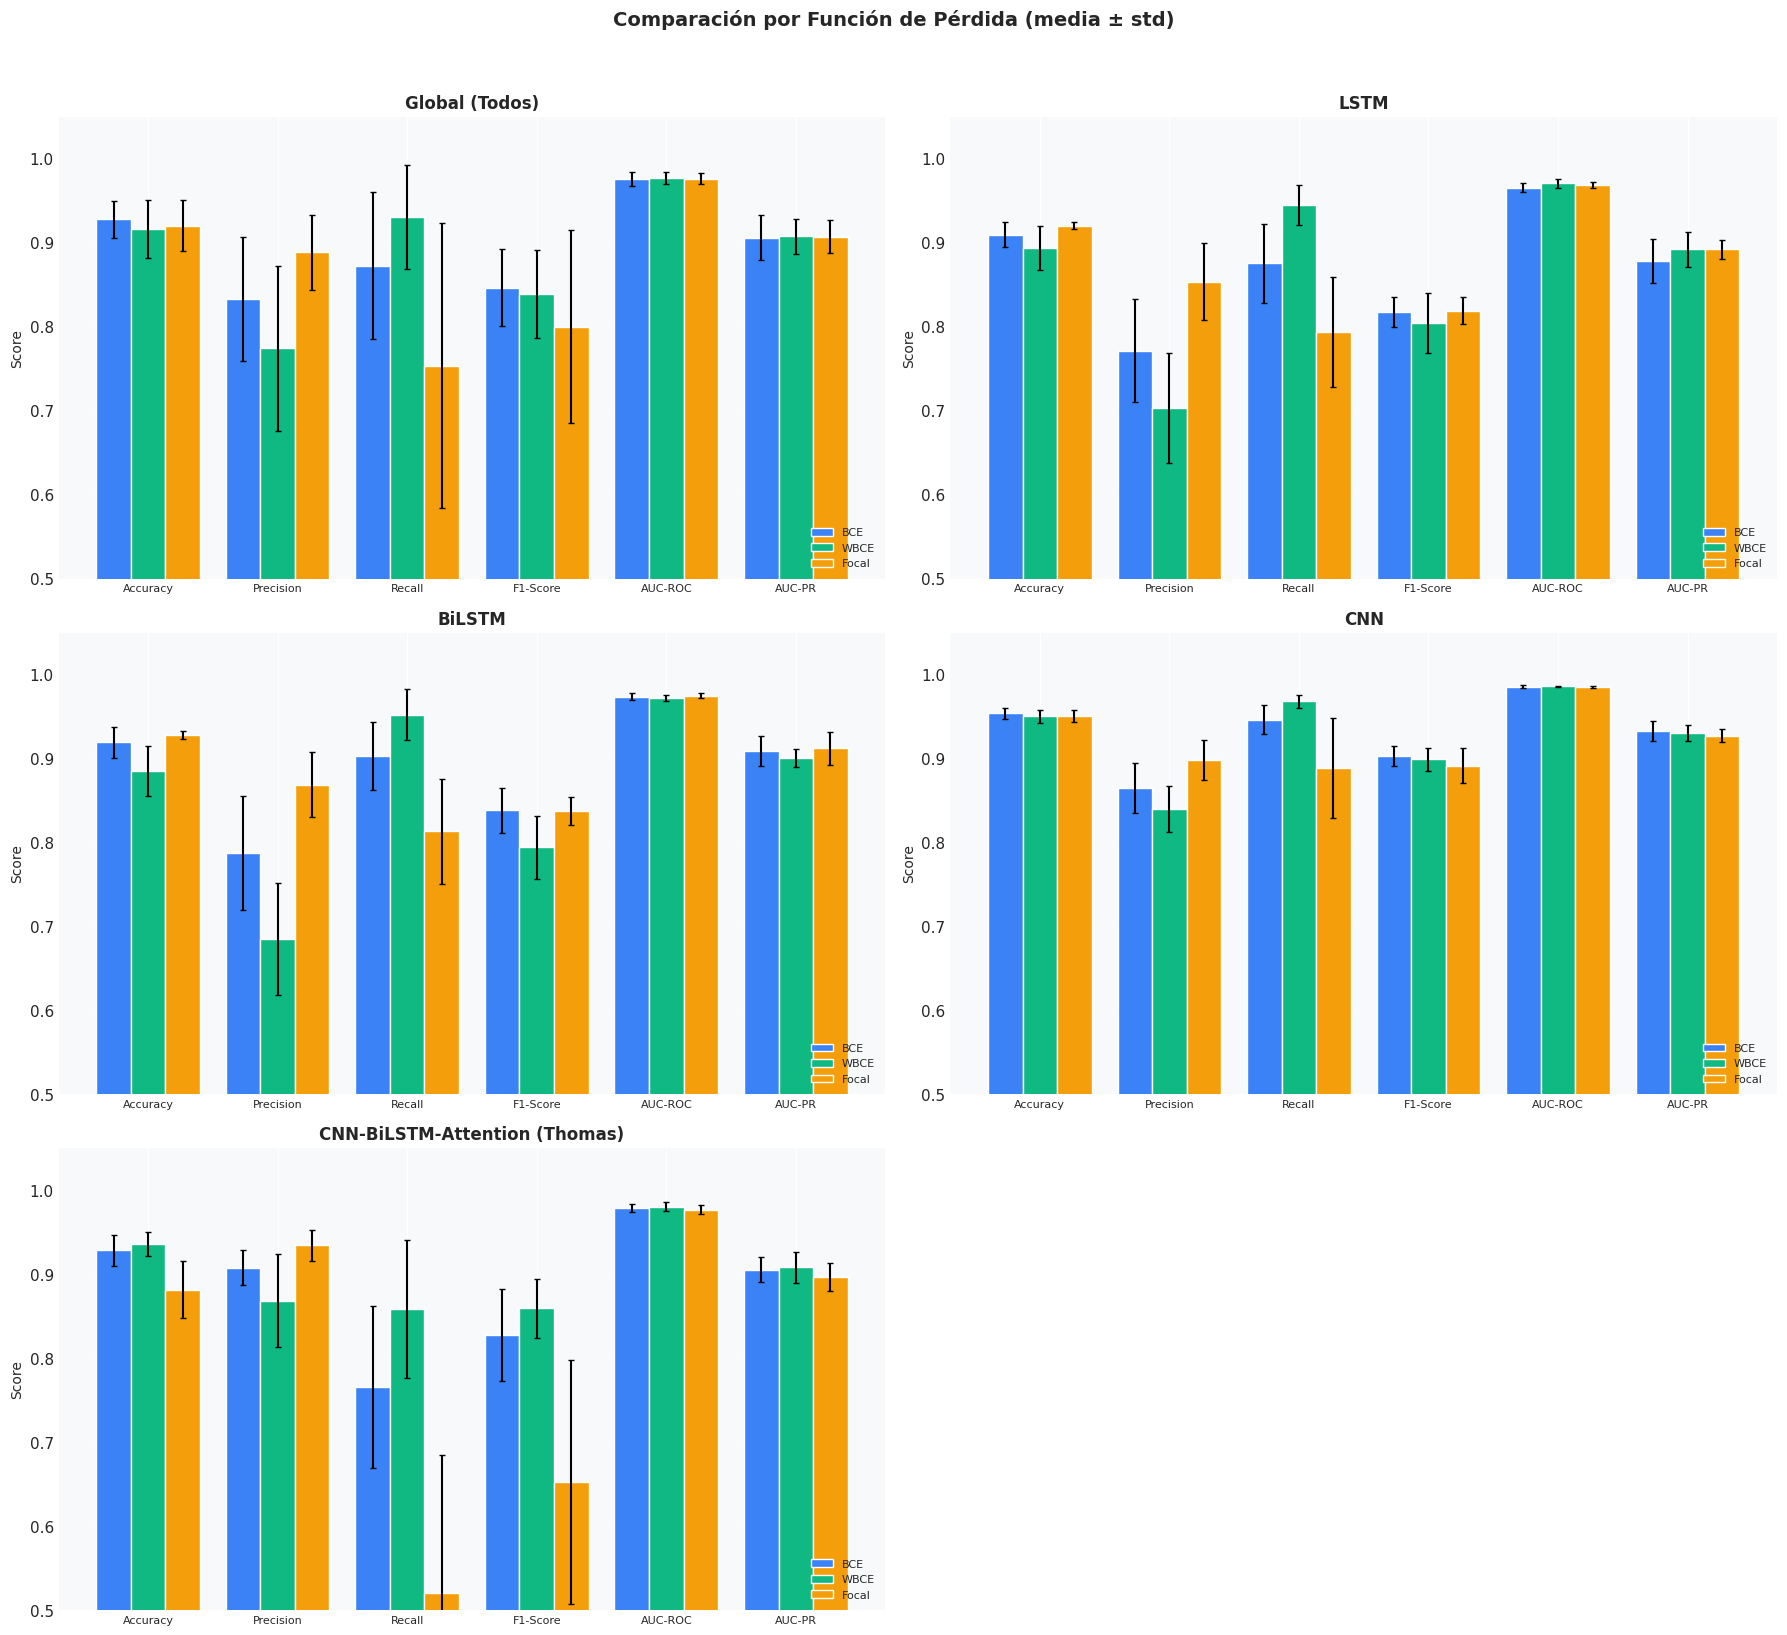

In [10]:
# ============================================================
# VISUALIZACIÓN 3: Comparación por Función de Pérdida (Loss Type)
# ============================================================
# 5 subplots: Global, LSTM, BiLSTM, CNN, CNN-BiLSTM-Att

def plot_loss_comparison(ax, data_df, title):
    """Genera gráfico de barras comparando por loss type."""
    main_metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_auc_roc', 'test_auc_pr']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']
    
    if len(data_df) == 0:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(title, fontsize=12, fontweight='bold')
        return
    
    loss_grouped = data_df.groupby('loss_type').agg({
        'test_accuracy': ['mean', 'std'],
        'test_precision': ['mean', 'std'],
        'test_recall': ['mean', 'std'],
        'test_f1': ['mean', 'std'],
        'test_auc_roc': ['mean', 'std'],
        'test_auc_pr': ['mean', 'std'],
    }).round(4)
    
    x = np.arange(len(main_metrics))
    loss_types = ['BCE', 'WBCE', 'Focal']
    n_loss = len([lt for lt in loss_types if lt in loss_grouped.index])
    width = 0.8 / max(n_loss, 1)
    
    for i, loss_type in enumerate(loss_types):
        if loss_type in loss_grouped.index:
            means = [loss_grouped.loc[loss_type, (m, 'mean')] for m in main_metrics]
            stds = [loss_grouped.loc[loss_type, (m, 'std')] for m in main_metrics]
            offset = (i - n_loss/2 + 0.5) * width
            ax.bar(x + offset, means, width, label=loss_type, yerr=stds, capsize=2, 
                   color=COLORS['loss'].get(loss_type, '#6b7280'), edgecolor='white')
    
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=8)
    ax.legend(loc='lower right', fontsize=8)
    ax.set_ylim(0.5, 1.05)
    ax.grid(True, alpha=0.3, axis='y')

fig, axes = plt.subplots(3, 2, figsize=(18, 16))

plot_loss_comparison(axes[0, 0], df, 'Global (Todos)')
plot_loss_comparison(axes[0, 1], df_lstm, 'LSTM')
plot_loss_comparison(axes[1, 0], df_bilstm, 'BiLSTM')
plot_loss_comparison(axes[1, 1], df_cnn, 'CNN')
plot_loss_comparison(axes[2, 0], df_thomas, 'CNN-BiLSTM-Attention (Thomas)')
axes[2, 1].axis('off')

plt.suptitle('Comparación por Función de Pérdida (media ± std)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

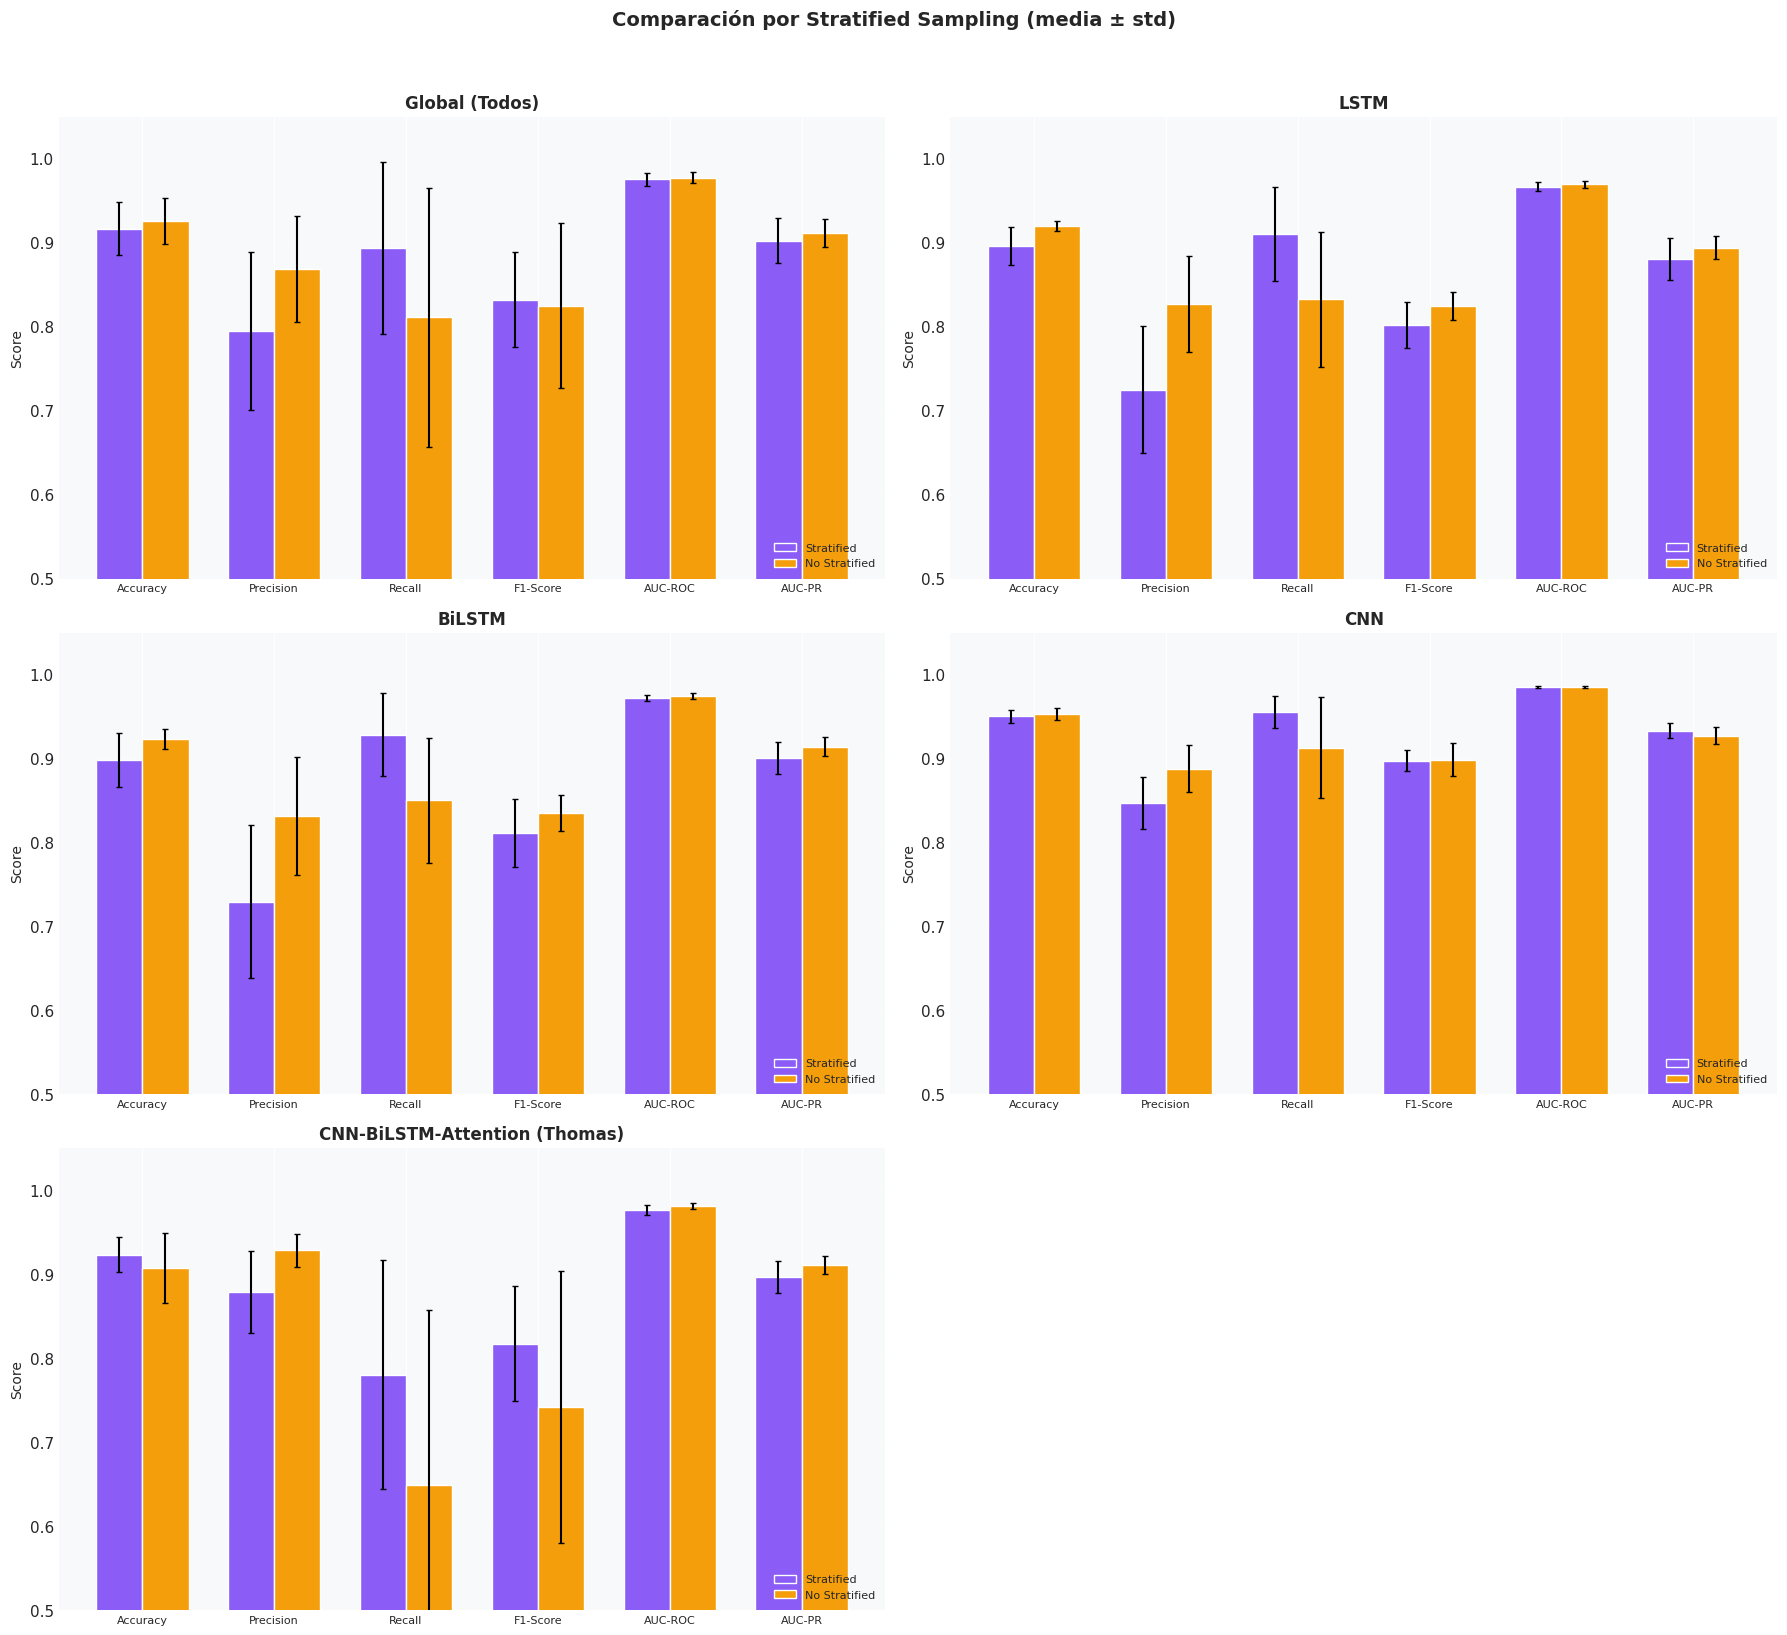

In [11]:
# ============================================================
# VISUALIZACIÓN 4: Comparación por Stratified Sampling
# ============================================================
# 5 subplots: Global, LSTM, BiLSTM, CNN, CNN-BiLSTM-Att

def plot_stratified_comparison(ax, data_df, title):
    """Genera gráfico de barras comparando por stratified sampling."""
    main_metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_auc_roc', 'test_auc_pr']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']
    
    if len(data_df) == 0:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(title, fontsize=12, fontweight='bold')
        return
    
    strat_grouped = data_df.groupby('use_stratified_sampling').agg({
        'test_accuracy': ['mean', 'std'],
        'test_precision': ['mean', 'std'],
        'test_recall': ['mean', 'std'],
        'test_f1': ['mean', 'std'],
        'test_auc_roc': ['mean', 'std'],
        'test_auc_pr': ['mean', 'std'],
    }).round(4)
    
    x = np.arange(len(main_metrics))
    width = 0.35
    
    for i, (use_strat, label) in enumerate([(True, 'Stratified'), (False, 'No Stratified')]):
        if use_strat in strat_grouped.index:
            means = [strat_grouped.loc[use_strat, (m, 'mean')] for m in main_metrics]
            stds = [strat_grouped.loc[use_strat, (m, 'std')] for m in main_metrics]
            offset = (i - 0.5) * width
            ax.bar(x + offset, means, width, label=label, yerr=stds, capsize=2, 
                   color=COLORS['stratified'].get(use_strat, '#6b7280'), edgecolor='white')
    
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=8)
    ax.legend(loc='lower right', fontsize=8)
    ax.set_ylim(0.5, 1.05)
    ax.grid(True, alpha=0.3, axis='y')

fig, axes = plt.subplots(3, 2, figsize=(18, 16))

plot_stratified_comparison(axes[0, 0], df, 'Global (Todos)')
plot_stratified_comparison(axes[0, 1], df_lstm, 'LSTM')
plot_stratified_comparison(axes[1, 0], df_bilstm, 'BiLSTM')
plot_stratified_comparison(axes[1, 1], df_cnn, 'CNN')
plot_stratified_comparison(axes[2, 0], df_thomas, 'CNN-BiLSTM-Attention (Thomas)')
axes[2, 1].axis('off')

plt.suptitle('Comparación por Stratified Sampling (media ± std)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4.2 Heatmap: F1-Score por Combinación

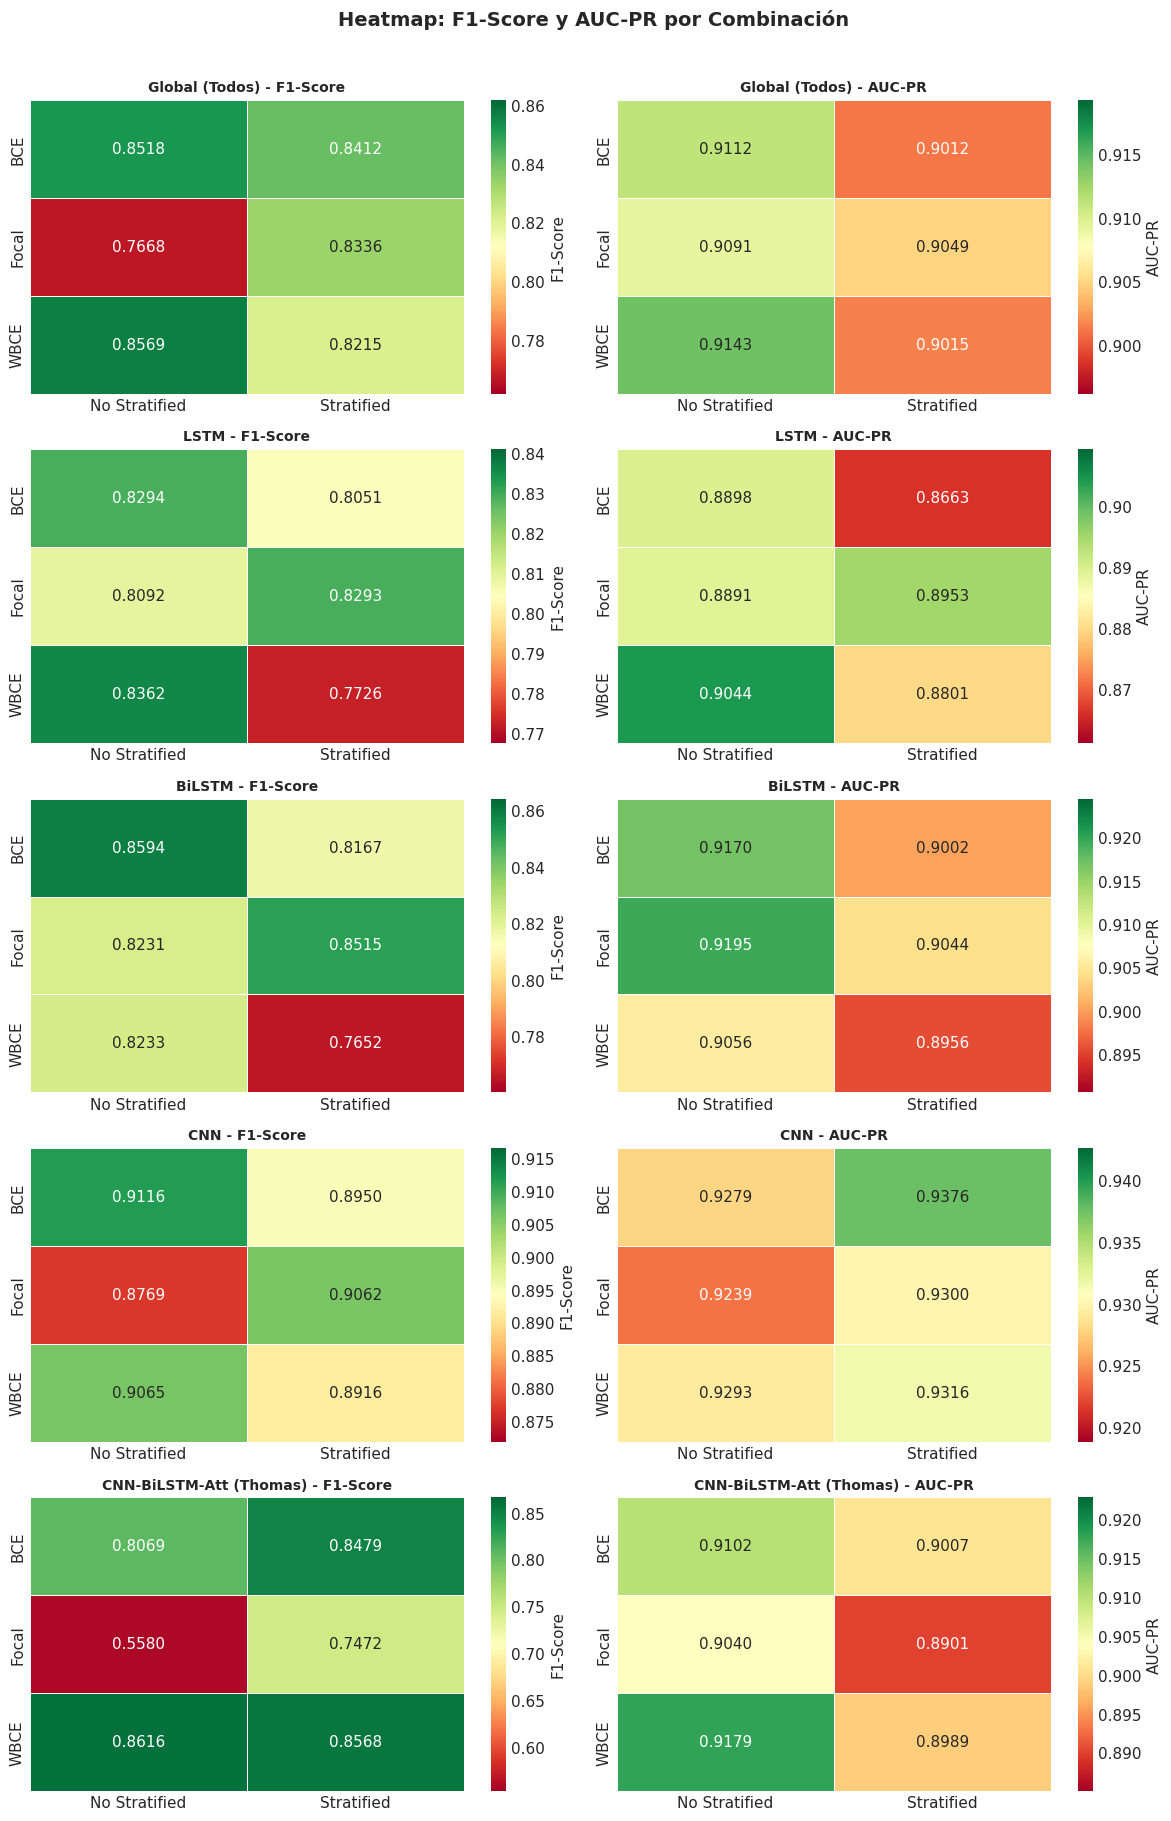

In [12]:
# ============================================================
# HEATMAP: F1-Score y AUC-PR por Loss Type y Stratified Sampling
# ============================================================
# 5 filas: Global, LSTM, BiLSTM, CNN, CNN-BiLSTM-Att

def plot_heatmaps(axes_row, data_df, row_title):
    """Genera heatmaps de F1-Score y AUC-PR para un conjunto de datos."""
    if len(data_df) == 0:
        for ax in axes_row:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes, fontsize=12)
        axes_row[0].set_ylabel(row_title, fontsize=11, fontweight='bold')
        return
    
    # Heatmap F1 medias
    pivot_f1 = data_df.pivot_table(values='test_f1', index='loss_type', columns='use_stratified_sampling', aggfunc='mean')
    if len(pivot_f1.columns) == 2:
        pivot_f1.columns = ['No Stratified', 'Stratified']
    pivot_f1 = pivot_f1.dropna(how='all')
    
    if len(pivot_f1) > 0:
        f1_min, f1_max = pivot_f1.values.min(), pivot_f1.values.max()
        sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='RdYlGn', ax=axes_row[0], 
                    vmin=f1_min - 0.005, vmax=f1_max + 0.005,
                    linewidths=0.5, cbar_kws={'label': 'F1-Score'})
    axes_row[0].set_title(f'{row_title} - F1-Score', fontsize=10, fontweight='bold')
    axes_row[0].set_xlabel('')
    axes_row[0].set_ylabel('')
    
    # Heatmap AUC-PR medias
    pivot_auc = data_df.pivot_table(values='test_auc_pr', index='loss_type', columns='use_stratified_sampling', aggfunc='mean')
    if len(pivot_auc.columns) == 2:
        pivot_auc.columns = ['No Stratified', 'Stratified']
    pivot_auc = pivot_auc.dropna(how='all')
    
    if len(pivot_auc) > 0:
        auc_min, auc_max = pivot_auc.values.min(), pivot_auc.values.max()
        sns.heatmap(pivot_auc, annot=True, fmt='.4f', cmap='RdYlGn', ax=axes_row[1],
                    vmin=auc_min - 0.005, vmax=auc_max + 0.005,
                    linewidths=0.5, cbar_kws={'label': 'AUC-PR'})
    axes_row[1].set_title(f'{row_title} - AUC-PR', fontsize=10, fontweight='bold')
    axes_row[1].set_xlabel('')
    axes_row[1].set_ylabel('')

fig, axes = plt.subplots(5, 2, figsize=(12, 18))

plot_heatmaps(axes[0], df, 'Global (Todos)')
plot_heatmaps(axes[1], df_lstm, 'LSTM')
plot_heatmaps(axes[2], df_bilstm, 'BiLSTM')
plot_heatmaps(axes[3], df_cnn, 'CNN')
plot_heatmaps(axes[4], df_thomas, 'CNN-BiLSTM-Att (Thomas)')

plt.suptitle('Heatmap: F1-Score y AUC-PR por Combinación', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4.3 Tiempo de Entrenamiento

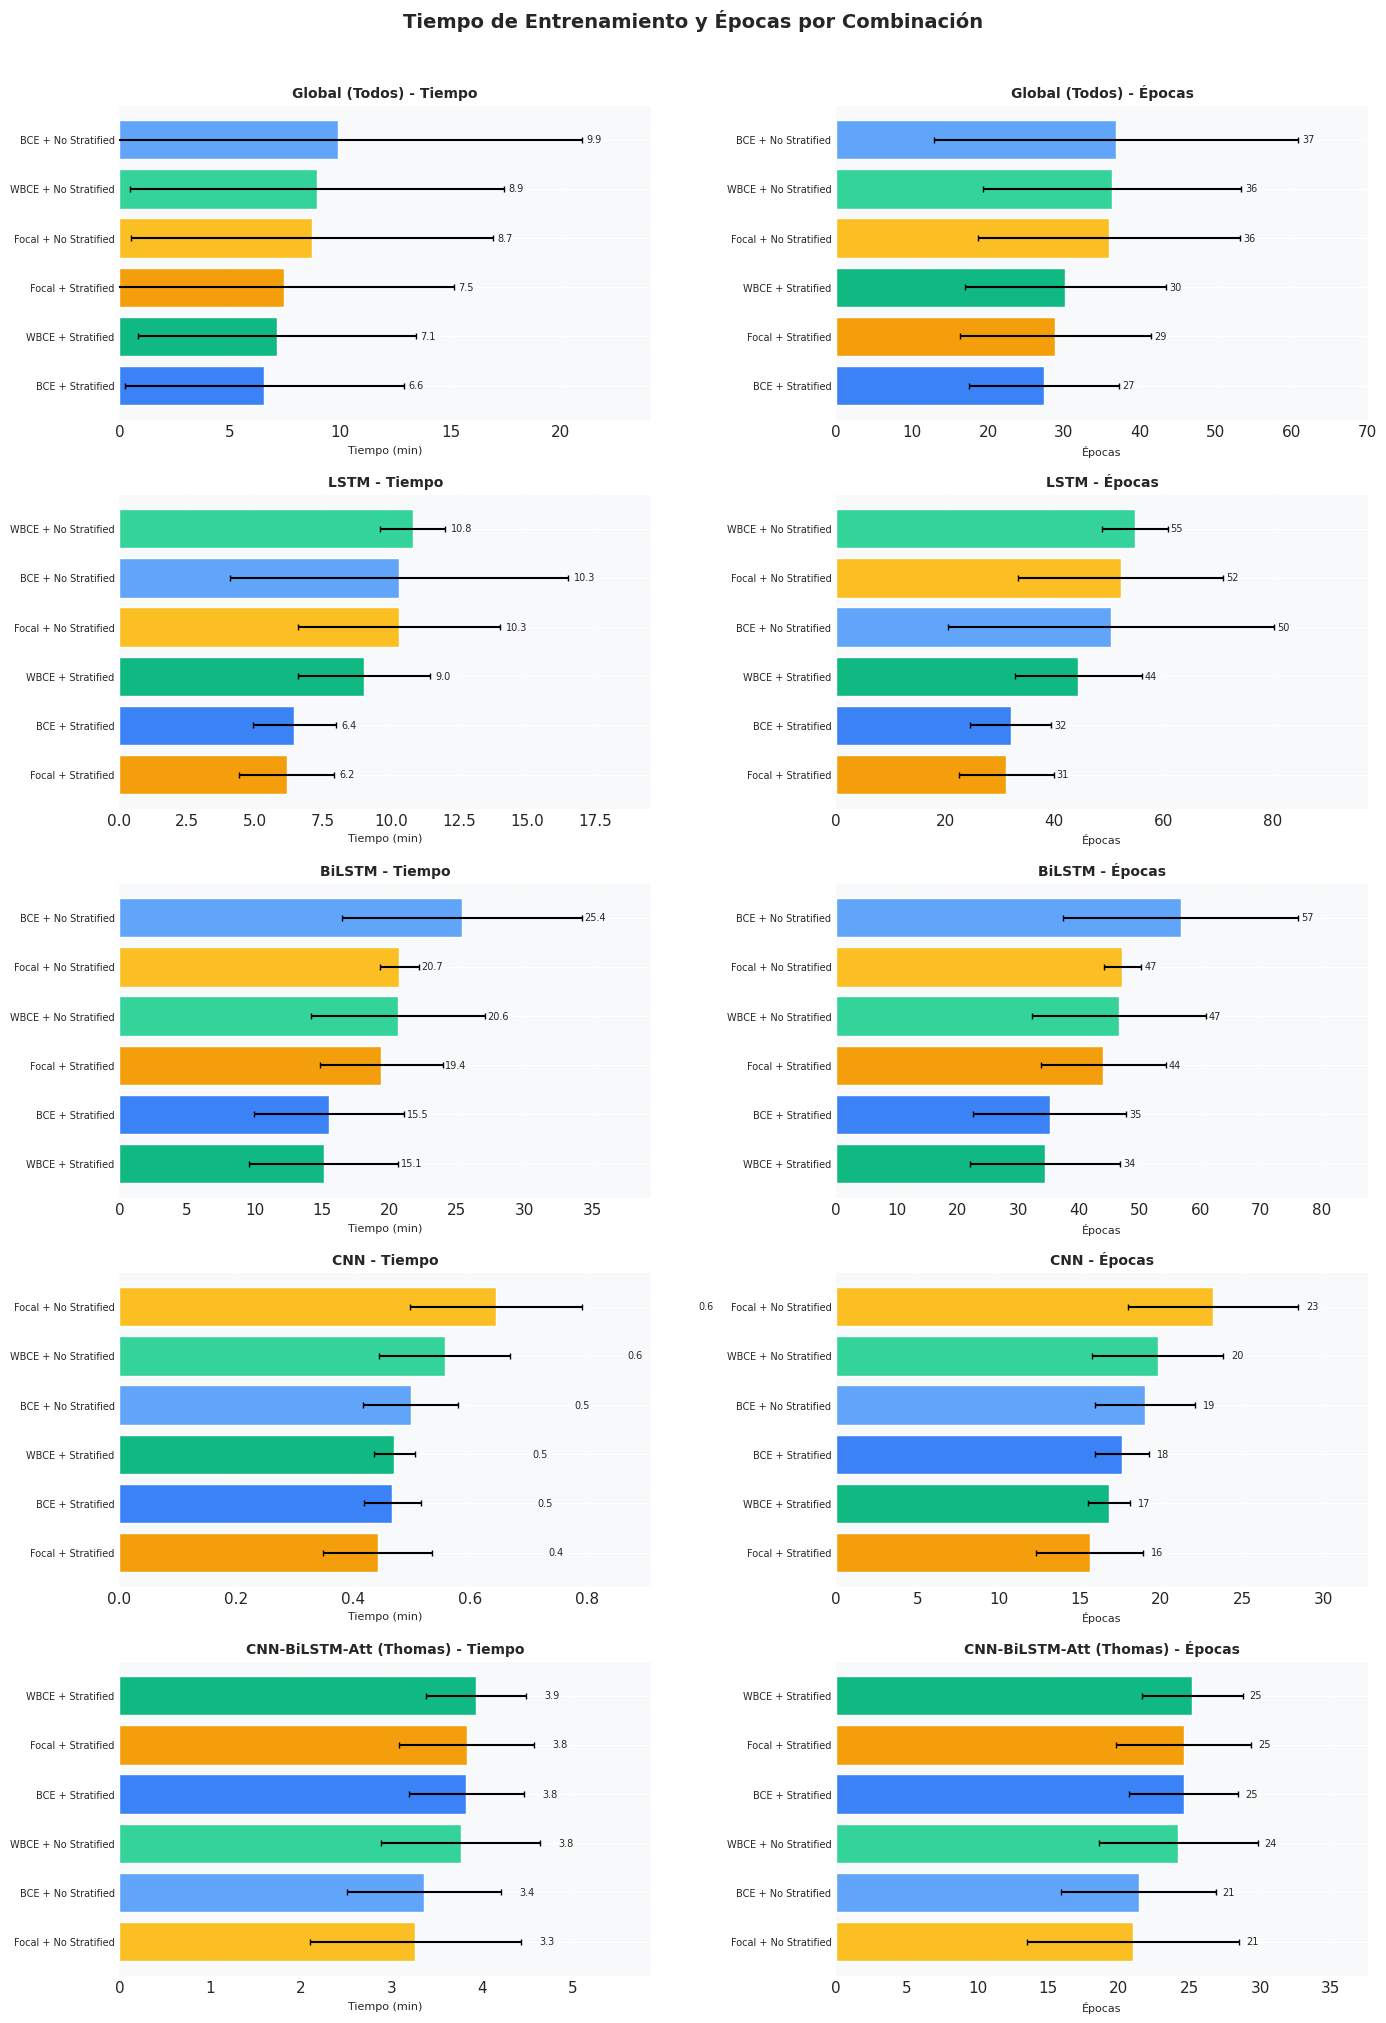

In [13]:
# ============================================================
# TIEMPO DE ENTRENAMIENTO POR COMBINACIÓN
# ============================================================
# 5 filas: Global, LSTM, BiLSTM, CNN, CNN-BiLSTM-Att

def plot_training_time(axes_row, data_df, row_title):
    """Genera gráficos de tiempo y épocas para un conjunto de datos."""
    if len(data_df) == 0:
        for ax in axes_row:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes, fontsize=12)
        axes_row[0].set_title(f'{row_title} - Tiempo', fontsize=10, fontweight='bold')
        axes_row[1].set_title(f'{row_title} - Épocas', fontsize=10, fontweight='bold')
        return
    
    # Gráfico 1: Tiempo promedio
    ax1 = axes_row[0]
    time_grouped = data_df.groupby('combo')['total_time_sec'].agg(['mean', 'std']).reset_index()
    time_grouped = time_grouped.sort_values('mean', ascending=True)
    
    colors_bar = [COLORS['combo'].get(c, '#6b7280') for c in time_grouped['combo']]
    bars = ax1.barh(time_grouped['combo'], time_grouped['mean'] / 60, 
                    xerr=time_grouped['std'] / 60, capsize=2, color=colors_bar, edgecolor='white')
    
    # Texto al final de la barra de error (mean + std)
    for bar, (_, row) in zip(bars, time_grouped.iterrows()):
        end_pos = (row['mean'] + row['std']) / 60  # Fin de la barra de error
        ax1.text(end_pos + 0.2, bar.get_y() + bar.get_height()/2, 
                 f'{row["mean"]/60:.1f}', va='center', fontsize=7)
    
    # Ajustar límites para que quepa el texto
    max_end = (time_grouped['mean'].max() + time_grouped['std'].max()) / 60
    ax1.set_xlim(0, max_end * 1.15)
    
    ax1.set_xlabel('Tiempo (min)', fontsize=8)
    ax1.set_title(f'{row_title} - Tiempo', fontsize=10, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
    ax1.tick_params(axis='y', labelsize=7)
    
    # Gráfico 2: Épocas
    ax2 = axes_row[1]
    epochs_grouped = data_df.groupby('combo')['actual_epochs'].agg(['mean', 'std']).reset_index()
    epochs_grouped = epochs_grouped.sort_values('mean', ascending=True)
    
    colors_bar2 = [COLORS['combo'].get(c, '#6b7280') for c in epochs_grouped['combo']]
    bars2 = ax2.barh(epochs_grouped['combo'], epochs_grouped['mean'], 
                     xerr=epochs_grouped['std'], capsize=2, color=colors_bar2, edgecolor='white')
    
    # Texto al final de la barra de error (mean + std)
    for bar, (_, row) in zip(bars2, epochs_grouped.iterrows()):
        end_pos = row['mean'] + row['std']  # Fin de la barra de error
        ax2.text(end_pos + 0.5, bar.get_y() + bar.get_height()/2, 
                 f'{row["mean"]:.0f}', va='center', fontsize=7)
    
    # Ajustar límites para que quepa el texto
    max_end = epochs_grouped['mean'].max() + epochs_grouped['std'].max()
    ax2.set_xlim(0, max_end * 1.15)
    
    ax2.set_xlabel('Épocas', fontsize=8)
    ax2.set_title(f'{row_title} - Épocas', fontsize=10, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.tick_params(axis='y', labelsize=7)

fig, axes = plt.subplots(5, 2, figsize=(14, 20))

plot_training_time(axes[0], df, 'Global (Todos)')
plot_training_time(axes[1], df_lstm, 'LSTM')
plot_training_time(axes[2], df_bilstm, 'BiLSTM')
plot_training_time(axes[3], df_cnn, 'CNN')
plot_training_time(axes[4], df_thomas, 'CNN-BiLSTM-Att (Thomas)')

plt.suptitle('Tiempo de Entrenamiento y Épocas por Combinación', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4.4 Ranking y Mejor Configuración

In [23]:
# ============================================================
# RANKING Y MEJOR CONFIGURACIÓN
# ============================================================
# 5 secciones: Global, LSTM, BiLSTM, CNN, CNN-BiLSTM-Attention

from IPython.display import display, Markdown

def print_ranking(agg_data, model_name):
    """Imprime ranking por F1-Score con todas las métricas como tabla Markdown."""
    if len(agg_data) == 0:
        display(Markdown(f"\n⚠️ **No hay datos de {model_name} para ranking**"))
        return
    
    ranking = agg_data.sort_values('test_f1_mean', ascending=False).reset_index(drop=True)
    
    # Build markdown table
    md = f"\n### 🏆 RANKING {model_name.upper()} (ordenado por F1-Score)\n\n"
    md += "| Pos | Combinación | F1-Score | Accuracy | Precision | Recall | AUC-PR | AUC-ROC |\n"
    md += "|:---:|:------------|:--------:|:--------:|:---------:|:------:|:------:|:-------:|\n"
    
    for i, row in ranking.iterrows():
        medal = "🥇" if i == 0 else "🥈" if i == 1 else "🥉" if i == 2 else f"{i+1}."
        
        f1 = f"{row['test_f1_mean']*100:.1f}±{row['test_f1_std']*100:.1f}"
        acc = f"{row['test_accuracy_mean']*100:.1f}±{row['test_accuracy_std']*100:.1f}"
        prec = f"{row['test_precision_mean']*100:.1f}±{row['test_precision_std']*100:.1f}"
        rec = f"{row['test_recall_mean']*100:.1f}±{row['test_recall_std']*100:.1f}"
        auc_pr = f"{row['test_auc_pr_mean']*100:.1f}"
        auc_roc = f"{row['test_auc_roc_mean']*100:.1f}"
        
        md += f"| {medal} | {row['combo']} | {f1} | {acc} | {prec} | {rec} | {auc_pr} | {auc_roc} |\n"
    
    display(Markdown(md))

# Rankings para cada grupo
print_ranking(agg_df_global, 'Global (Todos)')
print_ranking(agg_df, 'LSTM')
print_ranking(agg_df_bilstm, 'BiLSTM')
print_ranking(agg_df_cnn, 'CNN')
print_ranking(agg_df_thomas, 'CNN-BiLSTM-Att (Thomas)')



### 🏆 RANKING GLOBAL (TODOS) (ordenado por F1-Score)

| Pos | Combinación | F1-Score | Accuracy | Precision | Recall | AUC-PR | AUC-ROC |
|:---:|:------------|:--------:|:--------:|:---------:|:------:|:------:|:-------:|
| 🥇 | WBCE + No Stratified | 85.7±3.8 | 93.0±2.0 | 81.9±7.1 | 90.8±6.5 | 91.4 | 97.8 |
| 🥈 | BCE + No Stratified | 85.2±4.7 | 93.4±1.7 | 87.2±3.9 | 84.0±8.8 | 91.1 | 97.8 |
| 🥉 | BCE + Stratified | 84.1±4.3 | 92.1±2.4 | 79.4±7.8 | 90.6±7.0 | 90.1 | 97.5 |
| 4. | Focal + Stratified | 83.4±6.3 | 92.8±2.1 | 86.2±4.4 | 82.2±12.2 | 90.5 | 97.6 |
| 5. | WBCE + Stratified | 82.2±5.8 | 90.2±3.9 | 73.0±9.8 | 95.4±4.6 | 90.2 | 97.6 |
| 6. | Focal + No Stratified | 76.7±14.0 | 91.3±3.6 | 91.6±2.2 | 68.6±18.0 | 90.9 | 97.7 |



### 🏆 RANKING LSTM (ordenado por F1-Score)

| Pos | Combinación | F1-Score | Accuracy | Precision | Recall | AUC-PR | AUC-ROC |
|:---:|:------------|:--------:|:--------:|:---------:|:------:|:------:|:-------:|
| 🥇 | WBCE + No Stratified | 83.6±1.2 | 91.7±0.7 | 76.3±2.0 | 92.5±1.0 | 90.4 | 97.4 |
| 🥈 | BCE + No Stratified | 82.9±0.9 | 92.2±0.4 | 82.6±1.1 | 83.3±1.4 | 89.0 | 96.7 |
| 🥉 | Focal + Stratified | 82.9±1.0 | 92.0±0.3 | 81.4±2.3 | 84.8±3.9 | 89.5 | 96.9 |
| 4. | Focal + No Stratified | 80.9±1.3 | 92.0±0.5 | 89.4±0.7 | 73.9±1.9 | 88.9 | 96.9 |
| 5. | BCE + Stratified | 80.5±1.5 | 89.8±1.0 | 71.8±2.8 | 91.8±1.3 | 86.6 | 96.4 |
| 6. | WBCE + Stratified | 77.3±1.2 | 87.0±0.8 | 64.4±1.6 | 96.6±0.8 | 88.0 | 96.8 |



### 🏆 RANKING BILSTM (ordenado por F1-Score)

| Pos | Combinación | F1-Score | Accuracy | Precision | Recall | AUC-PR | AUC-ROC |
|:---:|:------------|:--------:|:--------:|:---------:|:------:|:------:|:-------:|
| 🥇 | BCE + No Stratified | 85.9±1.4 | 93.5±0.6 | 84.9±1.0 | 87.0±2.3 | 91.7 | 97.6 |
| 🥈 | Focal + Stratified | 85.2±0.7 | 93.1±0.4 | 83.4±1.6 | 87.0±1.9 | 90.4 | 97.4 |
| 🥉 | WBCE + No Stratified | 82.3±1.1 | 90.9±0.7 | 74.2±1.8 | 92.4±1.1 | 90.6 | 97.1 |
| 4. | Focal + No Stratified | 82.3±0.8 | 92.6±0.3 | 90.3±0.7 | 75.6±1.0 | 92.0 | 97.6 |
| 5. | BCE + Stratified | 81.7±1.3 | 90.4±0.9 | 72.5±2.5 | 93.6±1.7 | 90.0 | 97.1 |
| 6. | WBCE + Stratified | 76.5±2.6 | 86.2±2.0 | 62.8±3.4 | 98.0±0.3 | 89.6 | 97.3 |



### 🏆 RANKING CNN (ordenado por F1-Score)

| Pos | Combinación | F1-Score | Accuracy | Precision | Recall | AUC-PR | AUC-ROC |
|:---:|:------------|:--------:|:--------:|:---------:|:------:|:------:|:-------:|
| 🥇 | BCE + No Stratified | 91.2±0.7 | 95.9±0.3 | 89.0±1.0 | 93.4±1.4 | 92.8 | 98.5 |
| 🥈 | WBCE + No Stratified | 90.6±0.5 | 95.5±0.3 | 85.6±0.7 | 96.4±0.6 | 92.9 | 98.6 |
| 🥉 | Focal + Stratified | 90.6±0.7 | 95.6±0.3 | 87.8±1.0 | 93.7±1.6 | 93.0 | 98.5 |
| 4. | BCE + Stratified | 89.5±0.8 | 94.9±0.4 | 84.0±1.5 | 95.8±0.8 | 93.8 | 98.6 |
| 5. | WBCE + Stratified | 89.2±1.5 | 94.6±0.8 | 82.4±2.8 | 97.2±0.5 | 93.2 | 98.6 |
| 6. | Focal + No Stratified | 87.7±1.7 | 94.6±0.6 | 91.8±1.1 | 84.1±3.9 | 92.4 | 98.4 |



### 🏆 RANKING CNN-BILSTM-ATT (THOMAS) (ordenado por F1-Score)

| Pos | Combinación | F1-Score | Accuracy | Precision | Recall | AUC-PR | AUC-ROC |
|:---:|:------------|:--------:|:--------:|:---------:|:------:|:------:|:-------:|
| 🥇 | WBCE + No Stratified | 86.2±3.8 | 94.1±1.3 | 91.4±1.6 | 81.9±7.1 | 91.8 | 98.3 |
| 🥈 | WBCE + Stratified | 85.7±2.7 | 93.2±1.2 | 82.3±3.4 | 89.8±6.3 | 89.9 | 97.7 |
| 🥉 | BCE + Stratified | 84.8±4.7 | 93.4±1.7 | 89.2±1.4 | 81.2±8.0 | 90.1 | 97.7 |
| 4. | BCE + No Stratified | 80.7±4.8 | 92.2±1.6 | 92.4±1.0 | 72.1±7.9 | 91.0 | 98.1 |
| 5. | Focal + Stratified | 74.7±5.1 | 90.3±1.5 | 92.1±1.2 | 63.2±7.0 | 89.0 | 97.5 |
| 6. | Focal + No Stratified | 55.8±13.1 | 86.0±2.9 | 94.7±1.0 | 40.9±13.7 | 90.4 | 97.9 |


## 4.5 Resumen Final

In [22]:
# ============================================================
# RESUMEN FINAL: TABLA COMPLETA DE RESULTADOS
# ============================================================
# 4 secciones: Global, LSTM, BiLSTM, CNN

def print_summary_table(agg_data, model_name):
    """Imprime tabla resumen para un conjunto de datos."""
    if len(agg_data) == 0:
        print(f"\n⚠️ No hay datos de {model_name}")
        return
    
    print(f"\n📊 TABLA {model_name.upper()}")
    print("=" * 100)
    
    display_cols = ['combo', 'n_iterations', 'test_f1_str', 'test_auc_roc_str', 'test_auc_pr_str', 'test_accuracy_str']
    display_df = agg_data[display_cols].copy()
    display_df.columns = ['Combinación', 'N', 'F1-Score', 'AUC-ROC', 'AUC-PR', 'Accuracy']
    display_df = display_df.sort_values('F1-Score', ascending=False)
    
    print(display_df.to_string(index=False))

# Tablas para cada grupo
print_summary_table(agg_df_global, 'Global (Todos)')
print_summary_table(agg_df, 'LSTM')
print_summary_table(agg_df_bilstm, 'BiLSTM')
print_summary_table(agg_df_cnn, 'CNN')
print_summary_table(agg_df_thomas, 'CNN-BiLSTM-Att (Thomas)')

# Guardar resultados completos
if len(agg_df) > 0:
    agg_df.to_csv("data/results_lstm_aggregated.csv", index=False)
if len(agg_df_bilstm) > 0:
    agg_df_bilstm.to_csv("data/results_bilstm_aggregated.csv", index=False)
if len(agg_df_cnn) > 0:
    agg_df_cnn.to_csv("data/results_cnn_aggregated.csv", index=False)
if len(agg_df_thomas) > 0:
    agg_df_thomas.to_csv("data/results_thomas_aggregated.csv", index=False)
agg_df_global.to_csv("data/results_global_aggregated.csv", index=False)

print(f"\n✓ Resultados guardados en: data/results_*_aggregated.csv")
print(f"✓ Total experimentos analizados: {len(df)} (LSTM: {len(df_lstm)}, BiLSTM: {len(df_bilstm)}, CNN: {len(df_cnn)}, Thomas: {len(df_thomas)})")


📊 TABLA GLOBAL (TODOS)
          Combinación  N      F1-Score      AUC-ROC       AUC-PR     Accuracy
 WBCE + No Stratified 20  85.69 ± 3.80 97.85 ± 0.65 91.43 ± 1.20 93.03 ± 2.00
  BCE + No Stratified 20  85.18 ± 4.68 97.76 ± 0.74 91.12 ± 1.90 93.44 ± 1.73
     BCE + Stratified 20  84.12 ± 4.33 97.45 ± 0.90 90.12 ± 3.10 92.12 ± 2.38
   Focal + Stratified 20  83.36 ± 6.31 97.57 ± 0.72 90.49 ± 2.24 92.75 ± 2.05
    WBCE + Stratified 20  82.15 ± 5.80 97.60 ± 0.80 90.15 ± 2.50 90.23 ± 3.92
Focal + No Stratified 20 76.68 ± 14.01 97.70 ± 0.61 90.91 ± 1.58 91.30 ± 3.57

📊 TABLA LSTM
          Combinación  N     F1-Score      AUC-ROC       AUC-PR     Accuracy
 WBCE + No Stratified  5 83.62 ± 1.23 97.37 ± 0.22 90.44 ± 0.32 91.70 ± 0.72
  BCE + No Stratified  5 82.94 ± 0.86 96.74 ± 0.47 88.98 ± 1.68 92.16 ± 0.38
   Focal + Stratified  5 82.93 ± 0.98 96.91 ± 0.35 89.53 ± 1.26 92.03 ± 0.33
Focal + No Stratified  5 80.92 ± 1.29 96.85 ± 0.21 88.91 ± 0.82 92.03 ± 0.46
     BCE + Stratified  5 80.51 